# Section 1: Introduction and System Selection
The chosen system is option D, which is a "Mechanical System with High Damping". This is an overdamped spring mass, which is essentialy a system where such high damping causes the system to not oscillate at all, instead creeping towards equilibrium slowly. This is special because of the excessivly slow settling time it takes to reach equilibrium. The real world application for this is the fact that many things in todays day and age use shock absorbers that deal with changes in fractions of a second. Being able to model such events is crucial for testing and development as well as general safety. The governing ODE is $$ \frac{dx}{dt} = -\frac{k}{c} x + \frac{1}{c}  F(t) $$
where k is the spring constant force (stiffness) and c is damping coefficient. F(t) is the force equation and x is the displacement from equilibrium (we use a displacement of 1 meter here). The value that we use here is $$ \frac{k}{c} =  5000 $$ which is a very high damping rate. Then the slow force that we use the make it stiff is $$ F(t) = 10 sin(t) $$
When plugged in, the equation look like this:
$$ \frac{dx}{dt} = -5000x + 0.002\sin(t) $$

# Section 2: Demonstration of Stiffness

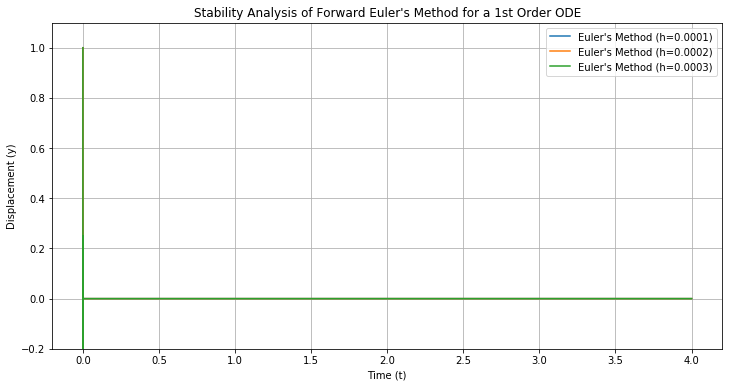

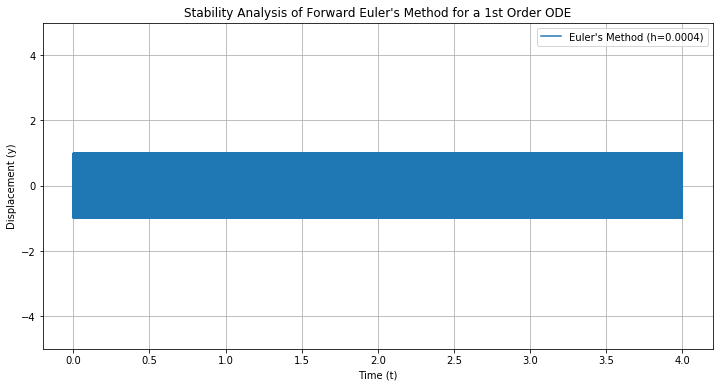

In [4]:
import numpy as np
import matplotlib.pyplot as plt
#The two functions that were derived at the beginning.
def f(y,t):
    return ((-5000*y) + (0.002 * np.sin(t)))


#Inputs for euler method are the 2 time points for the bounds, the starting position, 
# the step size, and then the h value. 
def euler_method(t_start, t_end, y_0, h):
    #create the t values using the unique step size h, and creates empty position and velocity lists
    t_values = np.arange(t_start, t_end + h, h)
    y_values = np.zeros(len(t_values))
    # Set initial conditions
    y_values[0] = y_0
    for i in range(1, len(t_values)):
        #Gets the previous position and velocity
        y_n = y_values[i - 1]
        t_n = t_values[i-1]
        # Updates values for Euler's Method
        y_values[i] = y_n + h * f(y_n,t_n)
    return (t_values, y_values)

h_values = [0.0001,0.0002,0.0003] 

#Backward Euler below
plt.figure(figsize=(12, 6))
for h in h_values:
    t, y = euler_method(0,4,1,h)
    plt.plot(t, y, label=f'Euler\'s Method (h={h})')
plt.ylim(-0.2,1.1)
plt.xlabel('Time (t)')
plt.ylabel('Displacement (y)')
plt.title('Stability Analysis of Forward Euler\'s Method for a 1st Order ODE')
plt.legend()
plt.grid(True)
plt.show()

h_values2 = [0.0004] 

#Backward Euler below for the one that will blow up because of a larger h value
plt.figure(figsize=(12, 6))
for h in h_values2:
    t, y = euler_method(0,4,1,h)
    plt.plot(t, y, label=f'Euler\'s Method (h={h})')
plt.ylim(-5,5)
plt.xlabel('Time (t)')
plt.ylabel('Displacement (y)')
plt.title('Stability Analysis of Forward Euler\'s Method for a 1st Order ODE')
plt.legend()
plt.grid(True)
plt.show()


**Discussion for Part 2**: It can be seen that the attempt with euler forward worked when the h value was super small with all three h values of 0.0001, 0.0002, and 0.0003 working and stabalizing to a displacement of zero by the end of the time limit. However, the next graph shows how a h value of 0.0004 caused it to break and be stuck oscillating between the bounds of -1 to 1 (caused by the sin function). This can be explained by calculating the forward euler stability limit, by using the formula that h has to be less than $$ \frac{2}{\lambda} $$ If we take our lambda value which is 5000 (from the given equation), the result is indeed 0.0004, which is where our euler broke at.

Furthermore, we can look at calculating the stiffness ratio. With the decay constant lambda being equal to 5000, the time constant is then 1/5000 which equals 0.0002 seconds. This super small value shows how quickly it "wants" to reach equilibrium.  Because the force has a fixed angular frequency of 1 rad/s (due to sin function), when can divide the 5000 by 1 (1 second for force to make noticeable change), resulting in a stifness ratio of 5000. This all is explained by understanding the two vastly different time scales going on at the same time. One process is trying to have something happen in 0.0002 seconds, while the other is taking a whole second. 

Since using an h value that is bigger than 0.0004 will cause forward euler to jump across the target, the overcorrection will cuase it to be unstable. So while forward euler does work, its computational cost is incredibly high for a stiff equation because it requires such a small time step (which isn't even needed for accuraccy, simply just to keep it from exploding). An implicit method is necessary here because we can solve for a future state with a much larger h value and the math will not explode. 

# Section 3: Euler's Backward Method with Newton-Raphson
The governing ODE is $$ \frac{dx}{dt} = -5000x + 0.002\sin(t) $$
The equation for solving using eulers backward is: $$ x_{n+1} = x_n + h * f(t_{t+1} , x_{n+1}) $$
Then we define the residual function by moving all the terms to one side, getting: $$ g(x_{n+1}) = x_{n+1} -x_n - h * f(t_{t+1} , x_{n+1}) =0 $$
Then we plug in our f function getting the equation of: 
 $$ g(x_{n+1}) = x_{n+1} -x_n - h * (-5000 x_{n+1} + 0.002 sin(t_{n+1})) =0 $$
 
 Now we have to find the derivative of g, which in this case means that the derivative of f with respect to x is -$\lambda$ (so just -5000). Therefore the full g prime equation is as follows: $$g'(x_{n+1}) = 1 + 5000h $$ This is a constant so it only is required to be computed once.
 Then we can type out our updated Newton-Raphson iteration by plugging in for the numerator the function for g that we derived above, and then the denominator as the slope we calculated: 
 $$x^{(k+1)}_{n+1} = x^{(k)}_{n+1} - \frac{x^{(k)}_{n+1} -x_n - h * (-5000 x^{(k)}_{n+1} + 0.002 sin(t_{n+1}))}{1+5000h} $$

# Section 4: Implementation

In [2]:
# The function that was derived in the instructions. This function will be used to simplify the code in the loops
def f(t,x):
    return (-5000*x + 0.002 * np.sin(t))
# This function simply returns the denominator in the function because the slope is constant. Makes loop more readable
def gprime(h):
    return(1+5000*h)

#Backward Euler method that takes essentially the same inputs as the forward euler method, just adding tolerance
def euler_backward(t_start, t_end, y_0, h,tolerance):
    def NR(xn,tn_1, h,tolerance):
        # set the first future guess as the current value
        future_guess = xn
        counter = 0 #counter that helps break after max of 20 iterations
        for i in range(21):
            #calculates the g equation defined above and checks if it already passes the tolerance test
            g_equation = future_guess - xn - (h * f(tn_1,future_guess))
            if np.abs(g_equation) < tolerance:
                break
            #uses the bigger equation to derive the new value for the guess
            temp_calculation = (g_equation) / (gprime(h))
            new_guess = future_guess - temp_calculation
            future_guess = new_guess
            counter +=1
            if counter == 20:
                break
        return (future_guess,counter)
    
    #initialize the empty iterations array for later, and create the t array and empty displacement array. 
    iterations_array = []    
    t_values = np.arange(t_start, t_end + h, h)
    y_values = np.zeros(len(t_values))
    # Set initial conditions
    y_values[0] = y_0
    for i in range(1, len(t_values)):
        #Gets the previous position and current time value 
        y_n = y_values[i - 1]
        t_n = t_values[i]
        # Updates values for Backward Euler Method using the Newton-Raphson Function above.
        y_values[i],temp_iteration = NR(y_n,t_n,h,tolerance)
        iterations_array.append(temp_iteration)
    return (t_values, y_values,iterations_array)
    
    
            
        
        


# Section 5: Result and Analysis

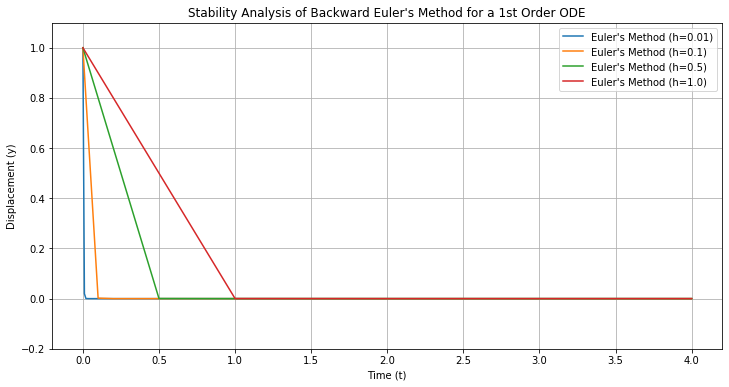

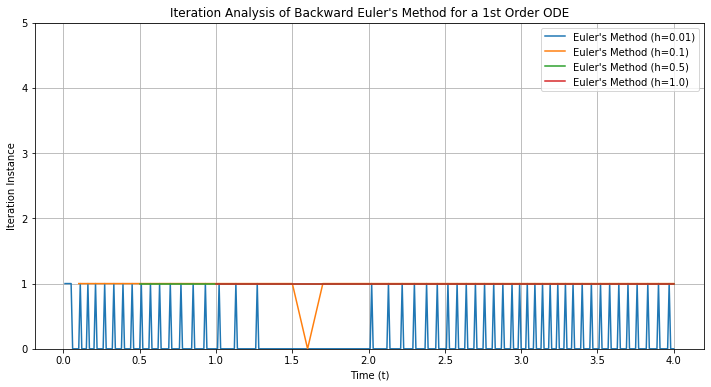

These are the averages iterations for each h value: [0.135, 0.975, 1.0, 1.0]


In [3]:
h_values = [0.01, 0.1,0.5,1.0] 
all_iterations = []
#Backwards Euler below that will use the function to plot the graph of displacement to time
plt.figure(figsize=(12, 6))
for h in h_values:
    end_val = h_values[-1]
    t, y, iteration_instance = euler_backward(0,4,1,h,0.000001)
    all_iterations.append(iteration_instance)
    plt.figure(1)
    plt.plot(t, y, label=f'Euler\'s Method (h={h})')
    
plt.ylim(-0.2,1.1)
plt.xlabel('Time (t)')
plt.ylabel('Displacement (y)')
plt.title('Stability Analysis of Backward Euler\'s Method for a 1st Order ODE')
plt.legend()
plt.grid(True)
plt.show()

# Another loop to plot the total iterations for each step compared to time
all_iterations = []
plt.figure(figsize=(12, 6))
for h in h_values:
    end_val = h_values[-1]
    t, y, iteration_instance = euler_backward(0,4,1,h,0.000001)
    all_iterations.append(iteration_instance)
    plt.plot(t[1:], iteration_instance, label=f'Euler\'s Method (h={h})')

       
plt.ylim(0,5)
plt.xlabel('Time (t)')
plt.ylabel('Iteration Instance')
plt.title('Iteration Analysis of Backward Euler\'s Method for a 1st Order ODE')
plt.legend()
plt.grid(True)
plt.show()

# simple loop that calculations the averages for each h step in the h_values list
averages = []
for i in all_iterations:
    sum_its = sum(i[0:])
    average_temp = sum_its / len(i)
    averages.append(average_temp)
print(f"These are the averages iterations for each h value: {averages}")



**Analysis**: We can see in the first graph where we plot the results from using eulers backward method that incorporates the newton raphson method. The results show that for all step sizes ranging from 0.01 to 1, they all reach equilibrium in their respective time intervals (h = 0.5 reached displacement of zero in 0.5 seconds). This shows how the system is unconditionally stable regardless of the h value. However it is important to note that the larger h values can be consider "lazy" as they just take longer to reach quilibrium (but are still gauranteed to do so). All of these h values would have blown up and not worked using the forward euler from above because they are all greater then the stability limit of h = 0.0004. 

Looking at the second graph, we can see the iterations taken in each time interval mapped out to the time, showing us how many iterations the newton raphson took to find each solution. We can see that for all h values, the iteration was never more than once. This is due to the fact that that the g' slope is constant, which means it is gauranteed to find the solution within an interation (something that wouldn't be gauranteed if the slope wasn't constant). The smallest h value had many instances where it's iteration was zero. This is because the previous guess was already less than the tolerance, so it didn't have to use the newton raphson method to find the better guess. The second smallest h value of 0.1 had this 0 iteration result exactly once. 


# Section 6: Performance Analysis 

| Method | Step Size (h) | Total Steps | Average NR Iterations | Total Function Evaluations |
| :--- | :---: | :---: | :--- |:--- |
| **Euler Forward** | 0.0001 | 40,000 | N/A | 40,000 | 
| **Euler Backward** | 0.01 | 400 | 0.135 | 54 | 
| **Euler Backward** | 0.1 | 40 | 0.975 | 39 | 


**Computational Cost Analysis**: We can see that at first glance, the backward euler could be more expensive because each step it makes has an inner loop that can increase the cost. However this is ok because of the fact that the backward euler with an h of 0.1 required 39 total calculations compared to forward euler at 40,000. This is roughly a 1000 fold reduction in total computational effort. Even with the smaller h step of 0.01 in backward euler still showed a similar total result of 54, which is essentially the same as the 0.1, both accurate and incredibly less costly than the forward euler. It is clear that doing more work in the finding of the next step is worth that extra work because of its ability to allow for larger h values

**Practical Recommendations**: To use this system, it makes sense that if the system you apply the functions to is indeed stiff, something like a lambda of 5000 in this case, that using backward euler is essentially a non-negotiable because it costs so much less to run. As for the step size h, it makes sense to think about what it is that you are looking for. If the little specific oscillations in the first few milliseconds are important, then using a h value that is smaller like 0.01 makes sense. However if the big picture matters more and finding the end state, then an h value of 0.1 or 0.5 work. just fine because they remain stable. An idea that works as well is that the h value can be dynamic, where since we know we need more accuracy in the first half, we can use a smaller h value there, but then crank it up when the system will be less active so it costs less to run there. 

# Section 7: Conclusions

There are many key findings in this analysis project that are worth note. The first is that newton raphson method is incredibly effective when dealing with a system that has a constant g', which is not always the case. This allowed this simulation of a stiff system of a spring to be solved with low total iterations in the newton raphson loop. However even if the iterations were higher, the precision would still allow for a higher h size than would be possible be the regular forward euler method. It is important to note that even for larger h values (such as the h = 1), the system is still stable and will not blow up and avoid the equilibrium. Rather, it just takes a much longer time and approach that can be useless in terms of the data it provides for the short time, but still gives you the effective final result. 

As for implicit for explicit methods, it is clear that using an explicit method is acceptable when the system of ODE's are not stiff and happen on relatively similar time scales. That allows for a simple forward euler to perform the analysis. However if a system is a "stiff" one, then it is computationally necessary to use an implicit method as backward euler due to the fact that not only does it lower total computational cost, but it allows for the use of a much larger h value when such small precision might not be needed for the results that are important for the specific analysis in mind. 

Some challenges that presented themselves were that of getting the derivation for the system of equations with the f function plugged in and getting the g equation. Another challenge was that of plotting the iterations to time, as the method chosen resorted to using the same loop again to then plot the different results. 